# # Phases 7–8 — Uncertainty, Practical Design Tool, Ablations
# Rock Fragmentation Prediction from Blast Parameters
#
# This notebook needs the **outputs of Notebook 02** (`oof_P2_rgkf.csv`,
# `oof_P3_loso.csv`) and, for the design-tool demo, the fitted models from
# **Notebook 03** (`models/final_models.joblib`). Add both as Kaggle Dataset
# inputs alongside `blast_master_110.csv` (e.g.
# `rock-blast-benchmark-outputs`).

## Setup — sync with the GitHub repository
This project's [GitHub repo](https://github.com/mobashshir-ubn-zainuddin/Rock-fragmentation-analysis-post-blasting)
holds the dataset and, after each notebook pushes, every table, figure and
fitted model produced on Kaggle — this is what lets Notebooks 02 -> 03 -> 04
share results without manually re-creating a Kaggle Dataset each time.

**One-time setup (already done if `GITHUB_TOKEN` appears under *Add-ons ->
Secrets*):** create a GitHub fine-grained personal access token scoped only
to this repository with **Contents: Read and write** permission, add it as
a Kaggle secret named `GITHUB_TOKEN`, and attach that secret to this
notebook. **Internet must be ON** (Session options, right panel).

The token is read fresh from Kaggle Secrets for every git operation and is
never written to disk (passed as a one-off `git -c http.extraheader=...`),
so it cannot leak even if this notebook's output is later made public.

This notebook needs the outputs of Notebooks 02 and 03 already pushed to GitHub (`oof_P2_rgkf.csv`, `oof_P3_loso.csv`, `final_models.joblib`) — `sync_repo()` above pulls them automatically.

In [11]:
import base64
import subprocess
from pathlib import Path

GITHUB_REPO = "mobashshir-ubn-zainuddin/Rock-fragmentation-analysis-post-blasting"
REPO_DIR = Path("/kaggle/working/repo")


def _github_token():
    try:
        from kaggle_secrets import UserSecretsClient
        token = UserSecretsClient().get_secret("GITHUB_TOKEN")
        print(f"GITHUB_TOKEN secret found (length {len(token)}).")
        return token
    except Exception as e:
        print(f"No GITHUB_TOKEN secret available ({type(e).__name__}: {e}); "
              "add one via Add-ons -> Secrets, attach it to this notebook, and "
              "turn Internet ON to enable GitHub sync. Falling back to the "
              "attached Kaggle dataset and /kaggle/working.")
        return None


def _auth_header(token):
    # GitHub's git-over-HTTPS endpoint expects HTTP Basic auth with the PAT as
    # the password (any non-empty username works; "x-access-token" is the
    # convention GitHub Actions itself uses) - NOT a bearer token, which is
    # only accepted by the REST/GraphQL API, not git's smart-HTTP protocol.
    basic = base64.b64encode(f"x-access-token:{token}".encode()).decode()
    return f"http.extraheader=AUTHORIZATION: basic {basic}"


def _git(*args, token=None, cwd=None):
    """Run git; if a token is given it is passed as a one-off HTTP auth header
    (``-c http.extraheader=...``) so it is never written to .git/config or to
    any file under /kaggle/working - safe even if this notebook's output is
    later made public."""
    cmd = ["git"]
    if token:
        cmd += ["-c", _auth_header(token)]
    cmd += list(args)
    r = subprocess.run(cmd, cwd=cwd, capture_output=True, text=True)
    if r.stdout.strip():
        print(r.stdout.strip())
    if r.returncode != 0 and r.stderr.strip():
        print(r.stderr.strip())
    return r


RESULTS_BRANCH = "kaggle-results"  # Kaggle never pushes to main, so it cannot clash with local work


def sync_repo():
    """Clone `main` (code + dataset) on first run in this session, then switch
    to the RESULTS_BRANCH, which holds every output pushed by earlier
    notebooks (created from main if it does not exist yet). Returns the local
    repo path, or None if no GITHUB_TOKEN secret is configured OR the sync
    actually failed (checked explicitly - git failures are not silently
    treated as success)."""
    token = _github_token()
    if token is None:
        return None
    import shutil
    REPO_DIR.parent.mkdir(parents=True, exist_ok=True)
    _git("config", "--global", "--add", "safe.directory", str(REPO_DIR))
    url = f"https://github.com/{GITHUB_REPO}.git"
    if (REPO_DIR / ".git").exists():
        r1 = _git("-C", str(REPO_DIR), "fetch", "origin", "main", token=token)
        r2 = _git("-C", str(REPO_DIR), "reset", "--hard", "FETCH_HEAD", token=token)
        ok = r1.returncode == 0 and r2.returncode == 0
    else:
        if REPO_DIR.exists():
            # Leftover from an earlier failed sync or another notebook's
            # output - `git clone` refuses a non-empty, non-git directory.
            print(f"{REPO_DIR} exists but is not a git repository (leftover "
                  "from an earlier run) - removing it before cloning fresh.")
            shutil.rmtree(REPO_DIR)
        r = _git("clone", "--depth", "1", url, str(REPO_DIR), token=token)
        ok = r.returncode == 0 and (REPO_DIR / ".git").exists()
        if not ok:
            # A public repo can still be cloned anonymously if the token is
            # bad; reading works, but push_to_github() will still fail.
            print("Authenticated clone failed; retrying without a token "
                  "(works only if this repo is public) ...")
            if REPO_DIR.exists():
                shutil.rmtree(REPO_DIR)
            r = _git("clone", "--depth", "1", url, str(REPO_DIR))
            ok = r.returncode == 0 and (REPO_DIR / ".git").exists()
            if ok:
                print("Anonymous clone succeeded - this notebook can READ the "
                      "repo, but push_to_github() will fail until GITHUB_TOKEN "
                      "is valid and attached to THIS notebook.")
    if not ok:
        print("GitHub sync FAILED (see the git error above). Common causes: "
              "GITHUB_TOKEN not attached to THIS notebook (Add-ons -> Secrets "
              "-> tick the checkbox), Internet is OFF, the token expired, or "
              "its repo access/permissions don't cover this repo. Outputs "
              "will only be saved to /kaggle/working for this session.")
        return None
    _git("-C", str(REPO_DIR), "config", "user.email", "kaggle-bot@users.noreply.github.com")
    _git("-C", str(REPO_DIR), "config", "user.name", "Kaggle Notebook Bot")
    # Pick up results pushed by earlier notebooks, if the branch exists yet.
    rb = _git("-C", str(REPO_DIR), "fetch", "origin", RESULTS_BRANCH, token=token)
    if rb.returncode == 0:
        _git("-C", str(REPO_DIR), "checkout", "-B", RESULTS_BRANCH, "FETCH_HEAD")
        print(f"Checked out existing branch '{RESULTS_BRANCH}' (earlier results included).")
    else:
        _git("-C", str(REPO_DIR), "checkout", "-B", RESULTS_BRANCH)
        print(f"Branch '{RESULTS_BRANCH}' does not exist on GitHub yet (the "
              "error above is expected on the first run) - it will be created "
              "on the first push.")
    print(f"Repo synced at {REPO_DIR} (branch {RESULTS_BRANCH})")
    return REPO_DIR


def push_to_github(message, paths=("outputs",)):
    """Commit whatever changed under the given paths (relative to the repo
    root) and push to RESULTS_BRANCH. Safe to call repeatedly / after every
    chunk. It also pushes commits that earlier failed to push, and if the
    branch moved on GitHub in the meantime (e.g. you pushed to it from your
    laptop) it merges the remote branch in and retries once."""
    if REPO_DIR is None or not (REPO_DIR / ".git").exists():
        print("Repo not available (GitHub sync did not succeed earlier in "
              "this notebook) - skipping push. See the sync_repo() cell's "
              "output above for why.")
        return
    token = _github_token()
    if token is None:
        print("GITHUB_TOKEN no longer available - skipping push.")
        return
    repo = str(REPO_DIR)
    target = f"HEAD:refs/heads/{RESULTS_BRANCH}"
    _git("-C", repo, "add", *paths)
    _git("-C", repo, "commit", "-m", message)  # "nothing to commit" is fine: still push below
    push = _git("-C", repo, "push", "origin", target, token=token)
    if push.returncode != 0:
        print("Push rejected - merging the remote branch and retrying once ...")
        fetch = _git("-C", repo, "fetch", "origin", RESULTS_BRANCH, token=token)
        merge = (_git("-C", repo, "merge", "--no-edit", "FETCH_HEAD")
                 if fetch.returncode == 0 else fetch)
        if merge.returncode != 0:
            _git("-C", repo, "merge", "--abort")
            print("Could not merge the remote branch automatically (see the git "
                  "output above). Your commits are safe in /kaggle/working/repo; "
                  "do NOT force-push. Fetch + merge origin/" + RESULTS_BRANCH +
                  " by hand, then call push_to_github() again.")
            return
        push = _git("-C", repo, "push", "origin", target, token=token)
    if push.returncode != 0:
        print("Push FAILED (see the git error above) - everything is still "
              "committed locally in /kaggle/working/repo and the next "
              "push_to_github() call will try again. If the error says "
              "403/permission denied, the token lacks Contents: Read and "
              "write on this repo.")
    else:
        print(f"Pushed to branch '{RESULTS_BRANCH}'.")


REPO_DIR = sync_repo()

GITHUB_TOKEN secret found (length 93).
HEAD is now at ef47afa 03: give models a DataFrame in parallel SHAP (no feature-name warnings)
Checked out existing branch 'kaggle-results' (earlier results included).
Repo synced at /kaggle/working/repo (branch kaggle-results)


In [12]:
import warnings
from pathlib import Path

import joblib
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

SEED = 42
CSV = None
for root in [Path("/kaggle/input"), REPO_DIR / "data" if REPO_DIR else None, Path("../data/processed")]:
    if root is not None and root.exists():
        found = list(root.rglob("blast_master_110.csv"))
        if found:
            CSV = found[0]
            break
assert CSV is not None, "blast_master_110.csv not found in /kaggle/input, the GitHub repo, or ../data/processed"
# Notebook 02/03 outputs: read from the freshly git-pulled repo (sync_repo()
# above already fetched their pushed commits), falling back to a manually
# attached Kaggle Dataset of their /kaggle/working output if no token is set.
PREV_OUT = (REPO_DIR / "outputs") if REPO_DIR else Path("/kaggle/input")
OUT = (REPO_DIR / "outputs") if REPO_DIR else (Path("/kaggle/working") if Path("/kaggle/working").exists() else Path("../outputs"))
for sub in ["figures", "tables", "models"]:
    (OUT / sub).mkdir(parents=True, exist_ok=True)

df = pd.read_csv(CSV)
FEATURES = ["S_B", "H_B", "B_D", "T_B", "Pf", "XB", "E"]
TARGET = "X50"

oof_P2 = pd.read_csv(next(PREV_OUT.rglob("oof_P2_rgkf.csv")))
oof_P3 = pd.read_csv(next(PREV_OUT.rglob("oof_P3_loso.csv")))
final = joblib.load(next(PREV_OUT.rglob("final_models.joblib")))
print("Loaded OOF predictions and", list(final.keys()), "fitted models")

Loaded OOF predictions and ['XGB', 'RF', 'SVR', 'ANN'] fitted models


# ## 4.1 Split-conformal prediction intervals (Phase 7)
# We estimate a 90% prediction interval half-width as the (1−α)-quantile of
# |residual| on a calibration half of the out-of-fold predictions, evaluated
# on the other half, averaged over many random splits. Empirical coverage
# should land close to 90% under P2 (in-distribution folds); a drop under
# P3 (LOSO) would indicate the model is less reliable on unseen sites — an
# expected and important finding to report.

In [13]:
def conformal_coverage(oof, model, alpha=0.10, n_iter=200, seed=SEED):
    d = oof[(oof.model == model) & (oof.rep == oof.rep.iloc[0])]
    r = np.abs(d.y - d.pred).values
    rng = np.random.RandomState(seed)
    cover, width = [], []
    for _ in range(n_iter):
        perm = rng.permutation(len(r))
        cal, ev = perm[: len(r) // 2], perm[len(r) // 2:]
        n = len(cal)
        q = np.quantile(r[cal], min(1, np.ceil((n + 1) * (1 - alpha)) / n))
        cover.append(np.mean(r[ev] <= q))
        width.append(2 * q)
    return round(float(np.mean(cover)), 3), round(float(np.mean(width)), 3)


rows = []
for m in oof_P2.model.unique():
    c2, w2 = conformal_coverage(oof_P2, m)
    c3, w3 = conformal_coverage(oof_P3, m) if m in oof_P3.model.unique() else (np.nan, np.nan)
    rows.append({"model": m, "P2_coverage": c2, "P2_interval_width_m": w2,
                 "P3_coverage": c3, "P3_interval_width_m": w3})
conf = pd.DataFrame(rows).sort_values("P2_interval_width_m")
conf.to_csv(OUT / "tables/T8_conformal_coverage.csv", index=False)
conf

,model,P2_coverage,P2_interval_width_m,P3_coverage,P3_interval_width_m
4,ET,0.916,0.299,0.914,0.570
3,RF,0.912,0.314,0.912,0.636
7,CatB,0.915,0.336,0.916,0.603
6,LGBM,0.916,0.346,0.917,0.716
5,XGB,0.914,0.373,0.913,0.580
9,GPR,0.911,0.379,0.912,0.766
1,MVR,0.911,0.397,0.909,0.591
2,Ridge,0.913,0.416,0.910,0.612
8,SVR,0.912,0.437,0.913,0.873
10,ANN,0.908,0.489,0.910,1.190


# ## 4.2 Applicability domain
# A new blast design is flagged as **extrapolation** if any input falls
# outside the training min–max range, or if its Mahalanobis distance to the
# training-data centroid exceeds the 97.5th-percentile distance observed in
# the training set itself.

In [14]:
from scipy.spatial.distance import mahalanobis

Xtr = df[FEATURES].values
mu, cov_inv = Xtr.mean(0), np.linalg.pinv(np.cov(Xtr.T))
train_d = np.array([mahalanobis(x, mu, cov_inv) for x in Xtr])
MAHAL_THRESH = np.percentile(train_d, 97.5)
RANGE = df[FEATURES].agg(["min", "max"])


def in_domain(x_dict):
    x = np.array([x_dict[f] for f in FEATURES])
    range_ok = all(RANGE.loc["min", f] <= x_dict[f] <= RANGE.loc["max", f] for f in FEATURES)
    dist_ok = mahalanobis(x, mu, cov_inv) <= MAHAL_THRESH
    return range_ok and dist_ok


print("Training-range box:\n", RANGE)
print(f"Mahalanobis 97.5th-percentile threshold: {MAHAL_THRESH:.2f}")

Training-range box:
       S_B   H_B    B_D   T_B    Pf    XB      E
min  1.00  1.33  17.98  0.50  0.22  0.02   9.57
max  1.75  6.82  39.47  4.67  1.26  2.35  60.00
Mahalanobis 97.5th-percentile threshold: 4.43


# ## 4.3 Practical design-tool demo (Figure 9)
# For a representative site (Akdaglar quarry, median geometry) we sweep the
# powder factor `Pf` and plot the predicted X50 with its 90% conformal
# interval — the kind of chart a blasting engineer could use to select `Pf`
# for a target fragment size.

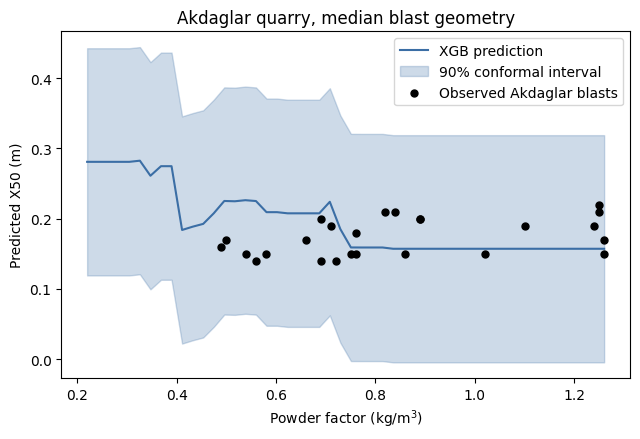

In [15]:
import matplotlib.pyplot as plt

best_model_name = "XGB"
q90 = np.quantile(np.abs(oof_P2.query("model == @best_model_name").y
                          - oof_P2.query("model == @best_model_name").pred), 0.9)

base = df[df.site == "Akdaglar"][FEATURES].median()
grid = pd.DataFrame([base] * 50)
grid["Pf"] = np.linspace(df.Pf.min(), df.Pf.max(), 50)
grid["in_domain"] = grid.apply(lambda r: in_domain(r[FEATURES].to_dict()), axis=1)
pred = final[best_model_name].predict(grid[FEATURES])

fig, ax = plt.subplots(figsize=(6.5, 4.5))
ax.plot(grid.Pf, pred, color="#3b6ea5", label=f"{best_model_name} prediction")
ax.fill_between(grid.Pf, pred - q90, pred + q90, alpha=0.25, color="#3b6ea5",
                 label="90% conformal interval")
ax.scatter(df[df.site == "Akdaglar"].Pf, df[df.site == "Akdaglar"].X50,
           color="black", s=25, zorder=5, label="Observed Akdaglar blasts")
ax.set_xlabel("Powder factor (kg/m$^3$)")
ax.set_ylabel("Predicted X50 (m)")
ax.set_title("Akdaglar quarry, median blast geometry")
ax.legend()
plt.tight_layout()
plt.savefig(OUT / "figures/F9_design_tool.png", dpi=300)
plt.show()

# ## 4.4 Ablation studies (Phase 8)
# Reuses the evaluation machinery from Notebook 02. Paste `metrics`,
# `repeated_group_kfold`, `build`, `space`, `tune`, `run_protocol` from
# Notebook 02 §2.2–2.5 above this cell if running standalone.

In [16]:
# --- minimal re-import of what's needed for ablations (see Notebook 02) ---
import time

from sklearn.compose import TransformedTargetRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GroupKFold, cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import FunctionTransformer, StandardScaler
from sklearn.svm import SVR
from xgboost import XGBRegressor
import optuna
from joblib import Parallel, delayed

optuna.logging.set_verbosity(optuna.logging.WARNING)

# Parallelism lives at the outer-fold level (all cores, one process per fold), so the
# models themselves run single-threaded. Results do not depend on the number of workers.
N_JOBS = -1


def metrics(y_true, y_pred):
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    return {"R2": r2_score(y_true, y_pred), "RMSE": mean_squared_error(y_true, y_pred) ** 0.5,
            "MAE": mean_absolute_error(y_true, y_pred),
            "MAPE": np.mean(np.abs((y_true - y_pred) / y_true)) * 100}


def logy(est):
    return TransformedTargetRegressor(regressor=est, func=np.log, inverse_func=np.exp)


def build_abl(name, p):
    if name == "MVR":
        return logy(make_pipeline(FunctionTransformer(np.log), LinearRegression()))
    if name == "RF":
        return RandomForestRegressor(random_state=SEED, n_jobs=1, **p)
    if name == "XGB":
        return XGBRegressor(random_state=SEED, n_jobs=1, verbosity=0, **p)
    if name == "SVR":
        return logy(make_pipeline(StandardScaler(), SVR(**p)))


def space_abl(name, t):
    if name == "RF":
        return {"n_estimators": t.suggest_int("n_estimators", 200, 800, step=100),
                "max_depth": t.suggest_int("max_depth", 2, 12),
                "min_samples_leaf": t.suggest_int("min_samples_leaf", 1, 8)}
    if name == "XGB":
        return {"n_estimators": t.suggest_int("n_estimators", 100, 600, step=50),
                "learning_rate": t.suggest_float("learning_rate", 0.01, 0.3, log=True),
                "max_depth": t.suggest_int("max_depth", 2, 6)}
    if name == "SVR":
        return {"C": t.suggest_float("C", 0.1, 1000, log=True),
                "epsilon": t.suggest_float("epsilon", 1e-3, 0.3, log=True),
                "gamma": t.suggest_float("gamma", 1e-3, 10, log=True)}
    return {}


def tune_abl(name, feats, Xtr, ytr, gtr, n_trials=20):
    if name == "MVR":
        return {}
    optuna.logging.set_verbosity(optuna.logging.WARNING)  # also inside worker processes
    cv = GroupKFold(n_splits=5)

    def obj(t):
        est = build_abl(name, space_abl(name, t))
        return -cross_val_score(est, Xtr, ytr, groups=gtr, cv=cv,
                                 scoring="neg_root_mean_squared_error").mean()

    st = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=SEED))
    st.optimize(obj, n_trials=n_trials, show_progress_bar=False)
    return space_abl(name, optuna.trial.FixedTrial(st.best_params))


def _ablation_task(feats, label, rep, fold, tr, te):
    """One outer fold of one feature-set ablation (runs in a worker process)."""
    Xa, ya = df[feats].values, df[TARGET].values
    ga = df.groupby(feats, sort=False).ngroup().values
    rows = []
    for name in ["MVR", "RF", "XGB", "SVR"]:
        p = tune_abl(name, feats, Xa[tr], ya[tr], ga[tr])
        est = build_abl(name, p).fit(Xa[tr], ya[tr])
        pred = est.predict(Xa[te])
        rows.append({"ablation": label, "rep": rep, "fold": fold,
                     "model": name, **metrics(ya[te], pred)})
    return rows


def run_ablation(feats, label, n_repeats=5):
    ga = df.groupby(feats, sort=False).ngroup().values
    rng = np.random.RandomState(SEED)
    uniq = np.unique(ga)
    tasks = []
    for rep in range(n_repeats):
        perm = rng.permutation(uniq)
        for fold, fg in enumerate(np.array_split(perm, 5)):
            te = np.isin(ga, fg)
            tasks.append((rep, fold, ~te, te))
    out = Parallel(n_jobs=N_JOBS, verbose=5)(
        delayed(_ablation_task)(feats, label, rep, fold, tr, te) for rep, fold, tr, te in tasks)
    return pd.DataFrame([r for rows in out for r in rows])


FEATURE_SETS = {
    "geometry_only": ["S_B", "H_B", "B_D", "T_B"],
    "geometry+Pf": ["S_B", "H_B", "B_D", "T_B", "Pf"],
    "all_7_features": FEATURES,
    "no_E_(site_proxy)": [f for f in FEATURES if f != "E"],
    "no_B_D": [f for f in FEATURES if f != "B_D"],
}
import re

CHUNK_DIR = OUT / "tables" / "chunks"
CHUNK_DIR.mkdir(parents=True, exist_ok=True)

abl_rows = []
for label, feats in FEATURE_SETS.items():
    # one saved chunk per feature set: an interrupted session resumes where it stopped
    # (delete outputs/tables/chunks/ablation__* to recompute, e.g. after changing settings)
    safe = re.sub(r"\W+", "_", label)
    chunk = CHUNK_DIR / f"ablation__{safe}.csv"
    if chunk.exists():
        print("Ablation:", label, "- already saved, skipping")
        abl_rows.append(pd.read_csv(chunk))
        continue
    print("Ablation:", label, feats)
    res = run_ablation(feats, label)
    res.to_csv(chunk, index=False)
    push_to_github(f"Notebook 04: ablation {label}", paths=["outputs"])
    abl_rows.append(res)
ablation_results = pd.concat(abl_rows, ignore_index=True)
ablation_results.to_csv(OUT / "tables/ablation_raw.csv", index=False)

ablation_summary = (ablation_results.groupby(["ablation", "model"])[["R2", "RMSE", "MAE", "MAPE"]]
                     .agg(["mean", "std"]).round(4))
ablation_summary.to_csv(OUT / "tables/T6_ablations.csv")
ablation_summary

Ablation: geometry_only ['S_B', 'H_B', 'B_D', 'T_B']


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Done  10 tasks      | elapsed:  6.6min
[Parallel(n_jobs=-1)]: Done  25 out of  25 | elapsed: 14.5min finished


GITHUB_TOKEN secret found (length 93).
[kaggle-results e5faa10] Notebook 04: ablation geometry_only
 3 files changed, 113 insertions(+)
 create mode 100644 outputs/figures/F9_design_tool.png
 create mode 100644 outputs/tables/T8_conformal_coverage.csv
 create mode 100644 outputs/tables/chunks/ablation__geometry_only.csv
Pushed to branch 'kaggle-results'.
Ablation: geometry+Pf ['S_B', 'H_B', 'B_D', 'T_B', 'Pf']


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Done  10 tasks      | elapsed:  6.9min
[Parallel(n_jobs=-1)]: Done  25 out of  25 | elapsed: 14.6min finished


GITHUB_TOKEN secret found (length 93).
[kaggle-results 0f00406] Notebook 04: ablation geometry+Pf
 1 file changed, 101 insertions(+)
 create mode 100644 outputs/tables/chunks/ablation__geometry_Pf.csv
Pushed to branch 'kaggle-results'.
Ablation: all_7_features ['S_B', 'H_B', 'B_D', 'T_B', 'Pf', 'XB', 'E']


...

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Done  10 tasks      | elapsed:  6.9min
[Parallel(n_jobs=-1)]: Done  25 out of  25 | elapsed: 15.2min finished


GITHUB_TOKEN secret found (length 93).
[kaggle-results b7ecef4] Notebook 04: ablation no_E_(site_proxy)
 1 file changed, 101 insertions(+)
 create mode 100644 outputs/tables/chunks/ablation__no_E__site_proxy_.csv
Pushed to branch 'kaggle-results'.
Ablation: no_B_D ['S_B', 'H_B', 'T_B', 'Pf', 'XB', 'E']


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Done  10 tasks      | elapsed:  7.6min
[Parallel(n_jobs=-1)]: Done  25 out of  25 | elapsed: 15.9min finished


GITHUB_TOKEN secret found (length 93).
[kaggle-results a6a0369] Notebook 04: ablation no_B_D
 1 file changed, 101 insertions(+)
 create mode 100644 outputs/tables/chunks/ablation__no_B_D.csv
Pushed to branch 'kaggle-results'.


R2            RMSE             MAE          \
                           mean     std    mean     std    mean     std   
ablation          model                                                   
all_7_features    MVR    0.5263  0.2466  0.1154  0.0356  0.0855  0.0210   
                  RF     0.7382  0.1643  0.0856  0.0308  0.0589  0.0169   
                  SVR    0.5798  0.2941  0.1068  0.0404  0.0714  0.0242   
                  XGB    0.7281  0.1560  0.0885  0.0312  0.0587  0.0159   
geometry+Pf       MVR    0.1954  0.2400  0.1554  0.0402  0.1170  0.0279   
                  RF     0.4701  0.2692  0.1224  0.0304  0.0883  0.0226   
                  SVR    0.3121  0.2163  0.1431  0.0317  0.1011  0.0221   
                  XGB    0.4965  0.2013  0.1206  0.0287  0.0881  0.0217   
geometry_only     MVR    0.0615  0.4520  0.1584  0.0407  0.1182  0.0279   
                  RF     0.3796  0.6702  0.1149  0.0275  0.0825  0.0189   
                  SVR    0.1764  0.3720  0.1496  0.0404  0.1073  0.0261   
                  XGB    0.4772  0.2728  0.1156  0.0231  0.0842  0.0170   
no_B_D            MVR    0.5323  0.2380  0.1151  0.0376  0.0843  0.0227   
                  RF     0.7462  0.1437  0.0848  0.0306  0.0585  0.0163   
                  SVR    0.6004  0.2669  0.1049  0.0404  0.0691  0.0233   
                  XGB    0.7165  0.2131  0.0890  0.0324  0.0587  0.0169   
no_E_(site_proxy) MVR    0.5241  0.2213  0.1161  0.0350  0.0879  0.0222   
                  RF     0.6083  0.1904  0.1045  0.0307  0.0726  0.0203   
                  SVR    0.5462  0.2822  0.1122  0.0378  0.0802  0.0270   
                  XGB    0.5819  0.2460  0.1077  0.0331  0.0729  0.0213   

                            MAPE           
                            mean      std  
ablation          model                    
all_7_features    MVR    31.3553   6.4053  
                  RF     24.0420  10.7735  
                  SVR    26.7989  11.7607  
                  XGB    23.8615  10.4636  
geometry+Pf       MVR    53.1032  25.5760  
                  RF     47.0393  27.7990  
                  SVR    44.2986  26.6910  
                  XGB    41.7351  26.2186  
geometry_only     MVR    54.7003  28.6693  
                  RF     46.4206  30.6959  
                  SVR    48.7029  30.5137  
                  XGB    42.1282  25.5222  
no_B_D            MVR    30.3035   5.5273  
                  RF     23.8331  10.5663  
                  SVR    26.0803  11.9913  
                  XGB    23.5812  10.4416  
no_E_(site_proxy) MVR    31.6935   5.4780  
                  RF     35.6790  15.1558  
                  SVR    32.1358  14.3321  
                  XGB    30.6787  12.3734

# ## 4.5 Additional robustness checks (Phase 8, quick versions)
# - **With vs. without Miami Mine (7 blasts)** — compares against studies
#   built on the 102/103-blast subset of the database.
# - **With vs. without Isolation-Forest-flagged rows** (from Notebook 01 §1.8).

In [17]:
from sklearn.ensemble import IsolationForest

iso_mask = IsolationForest(random_state=SEED, contamination=0.05).fit_predict(
    df[FEATURES + [TARGET]]) == -1

subsets = {
    "full_110": df.index.values,
    "without_Miami_103": df[df.site != "Miami"].index.values,
    "without_iso_outliers": df[~iso_mask].index.values,
}
def _robust_task(label, fold, Xs, ya, ga, tr, te):
    rows = []
    for name in ["RF", "XGB"]:
        p = tune_abl(name, FEATURES, Xs[tr], ya[tr], ga[tr], n_trials=15)
        est = build_abl(name, p).fit(Xs[tr], ya[tr])
        rows.append({"subset": label, "fold": fold, "model": name,
                     **metrics(ya[te], est.predict(Xs[te]))})
    return rows


tasks = []
for label, idx in subsets.items():
    sub = df.loc[idx]
    Xs, ya = sub[FEATURES].values, sub[TARGET].values
    ga = sub.groupby(FEATURES, sort=False).ngroup().values
    rng = np.random.RandomState(SEED)
    uniq = np.unique(ga)
    for fold, fg in enumerate(np.array_split(rng.permutation(uniq), 5)):
        te = np.isin(ga, fg)
        tasks.append((label, fold, Xs, ya, ga, ~te, te))
robust_rows = [row for rows in Parallel(n_jobs=N_JOBS, verbose=5)(
    delayed(_robust_task)(*t) for t in tasks) for row in rows]
robust = pd.DataFrame(robust_rows)
robust.to_csv(OUT / "tables/robustness_subsets.csv", index=False)
robust.groupby(["subset", "model"])[["R2", "RMSE"]].mean().round(4)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Done  12 out of  15 | elapsed:  5.8min remaining:  1.4min
[Parallel(n_jobs=-1)]: Done  15 out of  15 | elapsed:  7.0min finished


R2    RMSE
subset               model                
full_110             RF     0.7110  0.0837
                     XGB    0.7375  0.0827
without_Miami_103    RF     0.7195  0.0887
                     XGB    0.6756  0.0965
without_iso_outliers RF     0.6751  0.0873
                     XGB    0.6411  0.0910

# ## Outputs of this notebook
# - `tables/T8_conformal_coverage.csv`, `T6_ablations.csv`,
#   `robustness_subsets.csv`
# - `figures/F9_design_tool.png`
#
# All four notebooks together produce every table and figure referenced in
# `paper/paper.tex` (see `paper/make_tables.py` to auto-generate the LaTeX
# table files from these CSVs).

## Push results to GitHub
Final push of the conformal-coverage, ablation and robustness tables and the design-tool figure.

In [18]:
push_to_github("Notebook 04: uncertainty, design tool and ablations", paths=["outputs"])

GITHUB_TOKEN secret found (length 93).
[kaggle-results 78799f8] Notebook 04: uncertainty, design tool and ablations
 3 files changed, 555 insertions(+)
 create mode 100644 outputs/tables/T6_ablations.csv
 create mode 100644 outputs/tables/ablation_raw.csv
 create mode 100644 outputs/tables/robustness_subsets.csv
Pushed to branch 'kaggle-results'.
